In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1pkLk2s89-Etn7zIuYV88L_FvDH3sI8qx')
df.head()

,Unnamed: 0,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Precio Venta
0,0,city scrape,Nice room with superb city view,Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Nuttee,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,0.0,4.86,4.95,4.82,4.97,4.91,4.66,4.75,0.43,4.95
1,1,previous scrape,"Easy going landlord,easy place",Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Emy,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,0.0,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70
2,2,previous scrape,modern-style apartment in Bangkok,A modern-style apartment situated in a cool ne...,Ramkumheang neigbourhood - hip place with food...,Familyroom,12/05/2010,"Bangkok, Thailand",Welcome to Familyroom Apartment.\r\n\r\nA Chic...,within an hour,...,0.0,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70
3,3,city scrape,Spacious one bedroom at The Kris Condo Bldg. 3,Cozy and clean apartment at MRT Sutthisarn sta...,"There is McDonald's, Au bon Pain and Max Value...",Sirilak,27/06/2010,"Bangkok, Thailand",from Bangkok but I'm in and out of the city a ...,within an hour,...,0.0,4.83,5.00,4.67,4.50,4.83,4.83,5.00,0.06,5.00
4,4,city scrape,Condo with Chaopraya River View,at a size of 25sqm for your vacation in BKK.<b...,"There is McDonald's, Au bon Pain and Max Value...",Athitaya,03/09/2010,"Bangkok, Thailand","Full-time legal consultant from Bangkok, Thail...",within an hour,...,0.0,5.00,5.00,5.00,5.00,5.00,5.00,5.00,0.01,5.00


In [ ]:
df = df[df['room_type'] == 'Hotel room']

In [ ]:
df['price'] = df['price'].str.replace('$', '', regex=False)
df['price'] = df['price'].str.replace('.00', '', regex=False)
df['price'] = df['price'].str.replace(',000', '', regex=False)
df['price'] = df['price'].str.replace(',', '.', regex=False)
df['price'] = df['price'].astype(float)

In [ ]:
df['property_type'] = df['property_type'].replace({
    'Room in hostel': '7',
    'Room in serviced apartment': '6',
    'Room in boutique hotel': '5',
    'Room in bed and breakfast': '4',
    'Room in hotel': '3',
    'Room in aparthotel': '2',
    'Room in resort': '1'
}, regex=False)

<ipython-input-61-a79b0d0a01aa>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


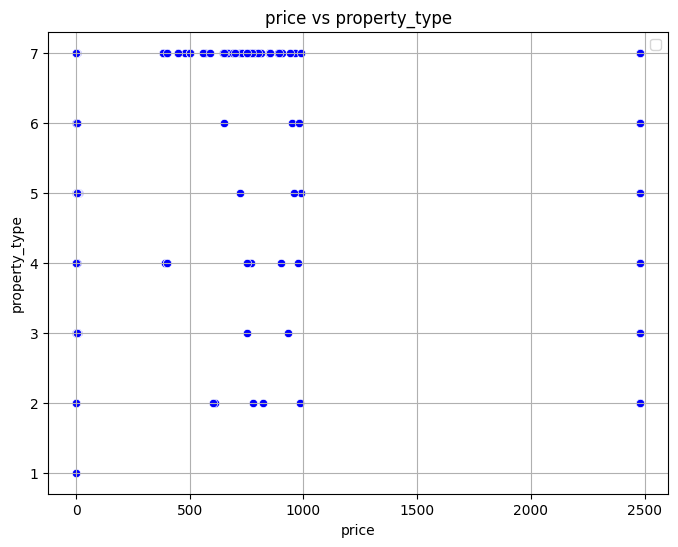

In [ ]:
from turtle import color

plt.figure(figsize=(8, 6))
sns.scatterplot(y='property_type', x='price',  color = 'blue', data=df)
plt.title('price vs property_type')
plt.xlabel('price')
plt.ylabel('property_type')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
indep= df[['property_type']]
dep = df[['price']]

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [ ]:
model.fit(indep, dep)

LinearRegression()

In [ ]:
type(model)

sklearn.linear_model._base.LinearRegression

In [ ]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['property_type'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([[71.52560235]]),
 'rank_': 1,
 'singular_': array([33.26847169]),
 'intercept_': array([938.37204687])}

In [ ]:
m = model.coef_
b = model.intercept_
print('Pendiente:', m)
print('Intercepto:', b)

# Entonce, el modelo lineal sería:
print(f'y = {m[0]}x + {b}')

Pendiente: [[71.52560235]]
Intercepto: [938.37204687]
y = [71.52560235]x + [938.37204687]


In [ ]:
r2 = model.score(indep, dep)
r2

0.009194339804968865

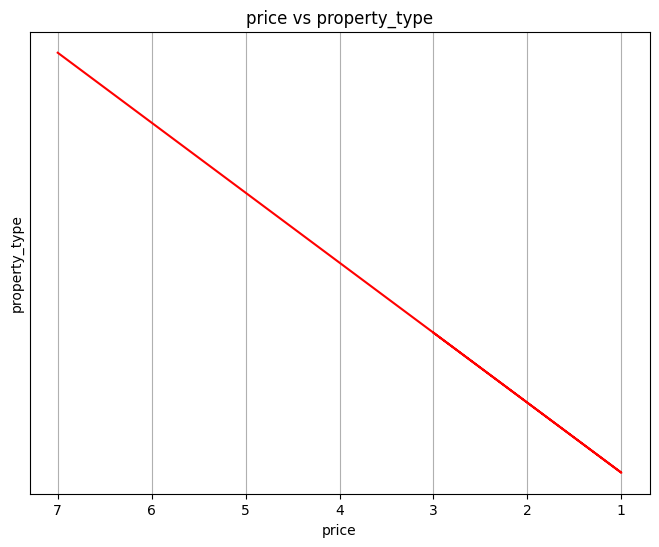

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(dep['price'], indep['property_type'], color='blue')
plt.plot(indep['property_type'], model.predict(indep), color='red')
plt.title('price vs property_type')
plt.xlabel('price')
plt.ylabel('property_type')
plt.grid(True)
plt.show()

In [ ]:
yPred = model.predict(df[['property_type']])
yPred

array([[1439.05126328],
       [1367.52566094],
       [1439.05126328],
       [1296.00005859],
       [1224.47445625],
       [1152.9488539 ],
       [1152.9488539 ],
       [1152.9488539 ],
       [1152.9488539 ],
       [1439.05126328],
       [1081.42325156],
       [1367.52566094],
       [1081.42325156],
       [1367.52566094],
       [1439.05126328],
       [1152.9488539 ],
       [1152.9488539 ],
       [1439.05126328],
       [1224.47445625],
       [1367.52566094],
       [1224.47445625],
       [1224.47445625],
       [1224.47445625],
       [1224.47445625],
       [1224.47445625],
       [1224.47445625],
       [1439.05126328],
       [1439.05126328],
       [1439.05126328],
       [1439.05126328],
       [1439.05126328],
       [1152.9488539 ],
       [1224.47445625],
       [1224.47445625],
       [1224.47445625],
       [1367.52566094],
       [1224.47445625],
       [1224.47445625],
       [1296.00005859],
       [1296.00005859],
       [1296.00005859],
       [1296.000

In [ ]:
df['Predicciones'] = yPred
df.head()

,Unnamed: 0,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Precio Venta,Predicciones
6,6,city scrape,Comfy bedroom near River pier & BTS Taksin.,This is one of our 'Escape' sleep room : hoste...,"Charoen krung street, River pier, Iconsiam, Su...",Tor,15/10/2010,"Bangkok, Thailand","Hello, my name is Tor, Escape at sathorn terra...",within a few hours,...,4.80,4.77,4.85,4.87,4.85,4.74,4.69,1.27,4.77,1439.051263
40,40,previous scrape,Luxury Riverview Teakwood Apartment-Great View...,"Attention: right now we are in Europe, so plea...",The exact location of the property is:<br /><b...,Maam & Hermann,12/04/2012,"Bangkok, Thailand",My thai wife Maam and me are living in this fl...,within an hour,...,4.83,4.91,4.89,4.82,4.89,4.54,4.84,0.80,4.91,1367.525661
198,198,city scrape,Baan Nampetch Hostel (Budget Double bedroom),Locate in Quiet area within 10 mins walking di...,We are locate in Payathai Area which comprise ...,Paula,04/09/2013,"Bangkok, Thailand",Do the best today and the the best for tomorro...,within an hour,...,4.65,4.70,4.86,4.83,4.79,4.58,4.65,1.18,4.70,1439.051263
329,329,city scrape,"Triple room,Near Grand Palace",Feung Nakorn Balcony : <br />Spacious room wit...,Feung Nakorn Balcony is the first and only bou...,Sasi,17/04/2014,"Krung Thep Maha Nakhon, Thailand",Hi we are family-run hostel in the middle of R...,within an hour,...,5.00,4.93,4.87,4.87,4.80,4.93,4.80,0.13,4.93,1296.000059
392,392,city scrape,"*Kingsize Boutique Room* 10min to Skytrain, WiFi",A very comfortable and cozy place in Sukhumvit...,Easy to get around: Train from Suvarnaphumi Ai...,Alex,01/08/2014,"Bangkok, Thailand",I am an authentic and passionate host. I love ...,within an hour,...,4.81,4.83,4.81,4.94,4.92,4.60,4.71,0.33,4.83,1224.474456


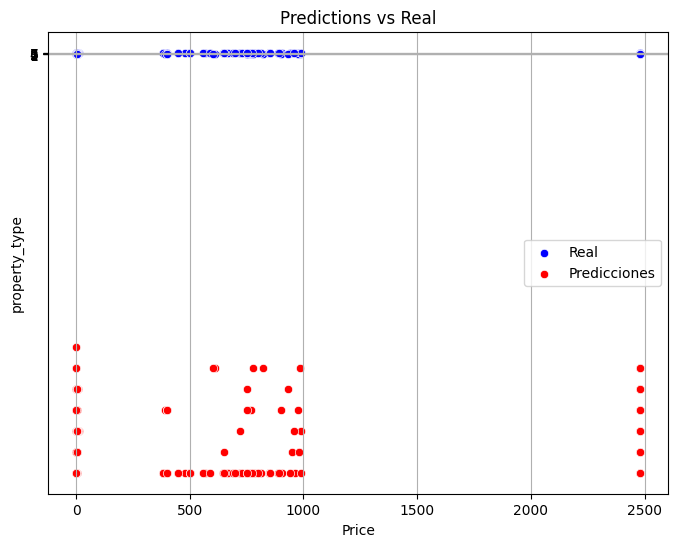

In [ ]:
plt.figure(figsize=(8, 6 ))
sns.scatterplot(x='price', y='property_type', color='blue', data=df, label='Real')
sns.scatterplot(x='price', y='Predicciones', color='red', data=df, label='Predicciones')
#sns.lineplot(x='alcohol', y='Predicciones', color='red', data=df, label='Predicciones')
plt.title('Predictions vs Real')
plt.xlabel('Price')
plt.ylabel('property_type')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
coefDe = model.score(indep, dep)
coefDe

0.009194339804968865

In [ ]:
coefCo = np.sqrt(coefDe)
coefCo

0.09588712012032098

In [ ]:
df['host_identity_verified'] = df['host_identity_verified'].replace({'t': 1, 'f': 0}).astype(int)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' Half-bath', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' bath', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' baths', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' Half-', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' Shared half-', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' shared half-', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' shared','', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' private bath', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' private', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' shared baths', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' Private half-', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' hared', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' S half-', '', regex=False)
df['bathrooms_text'] = pd.to_numeric(df['bathrooms_text'], errors='coerce')
#df['bathrooms_text'] = df['bathrooms_text'].astype(float)
df['host_is_superhost'] = df['host_is_superhost'].replace({'f': 0, 't': 1}).astype(float)
df['host_acceptance_rate'] = df['host_acceptance_rate'].str.replace('%', '', regex=False)
df['instant_bookable'] = df['instant_bookable'].replace({'f': 0, 't': 1}).astype(float)
df['host_acceptance_rate'] = df['host_acceptance_rate'].astype(float)
df['host_response_rate'] = df['host_response_rate'].str.replace('%', '', regex=False)
df['host_response_rate'] = df['host_response_rate'].astype(float)
df['has_availability'] = df['has_availability'].replace({'f': 0, 't': 1}).astype(float)

<ipython-input-75-a46314adb5de>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['host_identity_verified'] = df['host_identity_verified'].replace({'t': 1, 'f': 0}).astype(int)
<ipython-input-75-a46314adb5de>:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['host_is_superhost'] = df['host_is_superhost'].replace({'f': 0, 't': 1}).astype(float)
<ipython-input-75-a46314adb5de>:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `

In [ ]:
df = df[['host_acceptance_rate','host_is_superhost','price','accommodates','bathrooms_text','review_scores_cleanliness','host_identity_verified','instant_bookable','host_total_listings_count','bedrooms','review_scores_value','reviews_per_month','property_type']]

In [ ]:
correlacion = df.corr()
correlacion

,host_acceptance_rate,host_is_superhost,price,accommodates,bathrooms_text,review_scores_cleanliness,host_identity_verified,instant_bookable,host_total_listings_count,bedrooms,review_scores_value,reviews_per_month,property_type
host_acceptance_rate,1.000000,0.119295,-0.205075,0.037893,NaN,0.059355,-0.009566,0.237525,0.047577,-0.134614,0.046575,-0.070359,-0.140232
host_is_superhost,0.119295,1.000000,-0.084384,0.103905,NaN,0.067476,0.200111,0.079060,-0.108172,0.108019,0.025996,-0.086764,0.114061
price,-0.205075,-0.084384,1.000000,0.048884,NaN,-0.010178,-0.350336,-0.261709,-0.137367,0.171175,0.022354,0.065798,0.095887
accommodates,0.037893,0.103905,0.048884,1.000000,NaN,-0.084929,0.065255,-0.047566,0.070270,0.069803,-0.035302,-0.001289,0.096466
bathrooms_text,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_scores_cleanliness,0.059355,0.067476,-0.010178,-0.084929,NaN,1.000000,0.096252,0.110744,0.033889,-0.091205,0.588039,-0.427374,-0.040820
host_identity_verified,-0.009566,0.200111,-0.350336,0.065255,NaN,0.096252,1.000000,0.538337,0.081508,0.079812,0.095304,-0.209245,0.146663
instant_bookable,0.237525,0.079060,-0.261709,-0.047566,NaN,0.110744,0.538337,1.000000,0.132174,0.011930,0.091769,-0.109133,-0.085051
host_total_listings_count,0.047577,-0.108172,-0.137367,0.070270,NaN,0.033889,0.081508,0.132174,1.000000,0.021588,0.028790,-0.135721,0.024420
bedrooms,-0.134614,0.108019,0.171175,0.069803,NaN,-0.091205,0.079812,0.011930,0.021588,1.000000,-0.053747,0.021986,0.159502


In [ ]:
corr = abs(correlacion)
corr

,host_acceptance_rate,host_is_superhost,price,accommodates,bathrooms_text,review_scores_cleanliness,host_identity_verified,instant_bookable,host_total_listings_count,bedrooms,review_scores_value,reviews_per_month,property_type
host_acceptance_rate,1.000000,0.119295,0.205075,0.037893,NaN,0.059355,0.009566,0.237525,0.047577,0.134614,0.046575,0.070359,0.140232
host_is_superhost,0.119295,1.000000,0.084384,0.103905,NaN,0.067476,0.200111,0.079060,0.108172,0.108019,0.025996,0.086764,0.114061
price,0.205075,0.084384,1.000000,0.048884,NaN,0.010178,0.350336,0.261709,0.137367,0.171175,0.022354,0.065798,0.095887
accommodates,0.037893,0.103905,0.048884,1.000000,NaN,0.084929,0.065255,0.047566,0.070270,0.069803,0.035302,0.001289,0.096466
bathrooms_text,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_scores_cleanliness,0.059355,0.067476,0.010178,0.084929,NaN,1.000000,0.096252,0.110744,0.033889,0.091205,0.588039,0.427374,0.040820
host_identity_verified,0.009566,0.200111,0.350336,0.065255,NaN,0.096252,1.000000,0.538337,0.081508,0.079812,0.095304,0.209245,0.146663
instant_bookable,0.237525,0.079060,0.261709,0.047566,NaN,0.110744,0.538337,1.000000,0.132174,0.011930,0.091769,0.109133,0.085051
host_total_listings_count,0.047577,0.108172,0.137367,0.070270,NaN,0.033889,0.081508,0.132174,1.000000,0.021588,0.028790,0.135721,0.024420
bedrooms,0.134614,0.108019,0.171175,0.069803,NaN,0.091205,0.079812,0.011930,0.021588,1.000000,0.053747,0.021986,0.159502


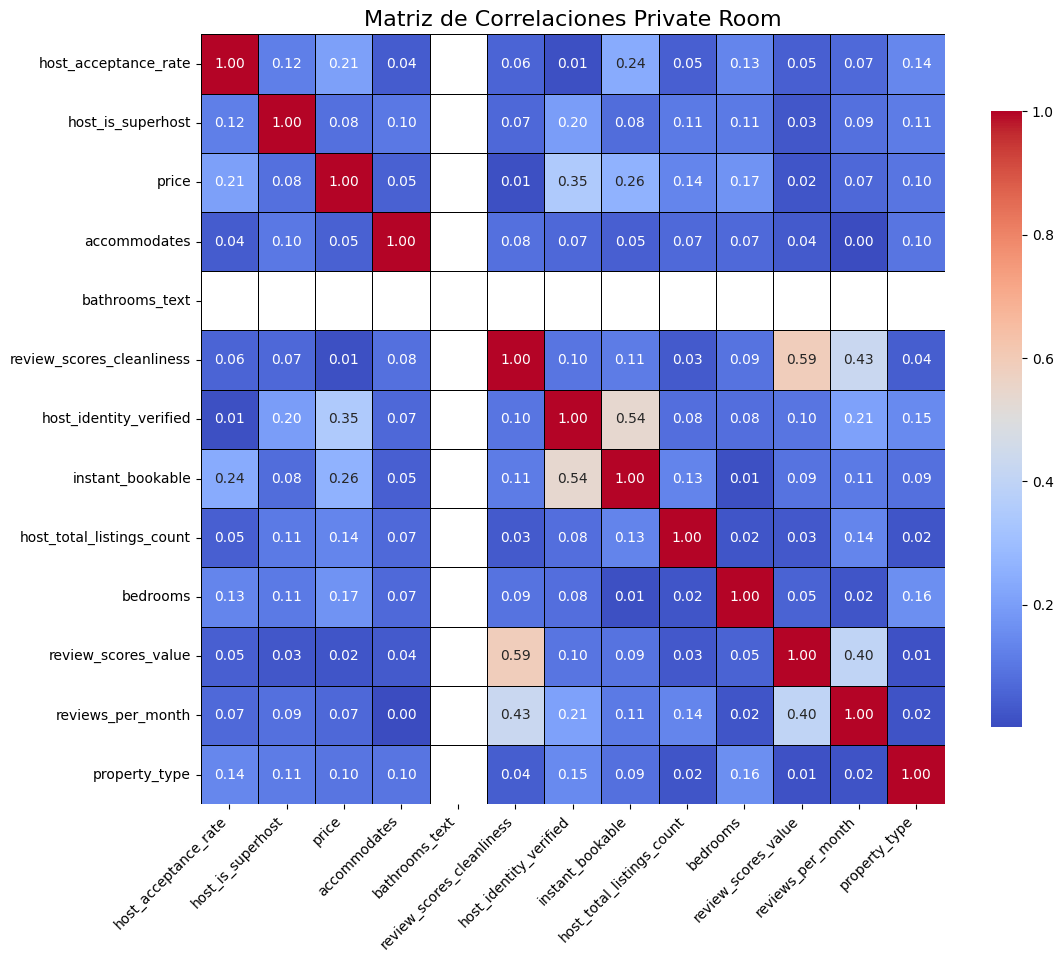

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, linecolor='black', cbar_kws={'shrink': 0.8}, annot_kws={"size": 10})
plt.title('Matriz de Correlaciones Private Room', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.show()